# COVID-19 Exercise - Lane A (the real experience: you prompt, the agent builds)

**SISMID 2026 - Day 2, 3:30.** You drive a coding agent (Codex, Claude Code, or Antigravity
CLI) to detect when a COVID-19 outbreak is taking off, and keep the judgment. For each
step: read the goal, paste the prompt, run the code, check the result.

> Each prompt produces roughly the matching cell in the **Lane B** notebook. Data:
> `covid_traces_WA.csv`.


## Step 0: load and look

> *Load covid_traces_WA.csv (daily, Washington State). In a 6-panel plot show new_cases*
> *and the five digital traces (upToDate, cdc_ili, Twitter_RelatedTweets, google_fever,*
> *Kinsa) over time. Which look leading vs lagging relative to cases?*


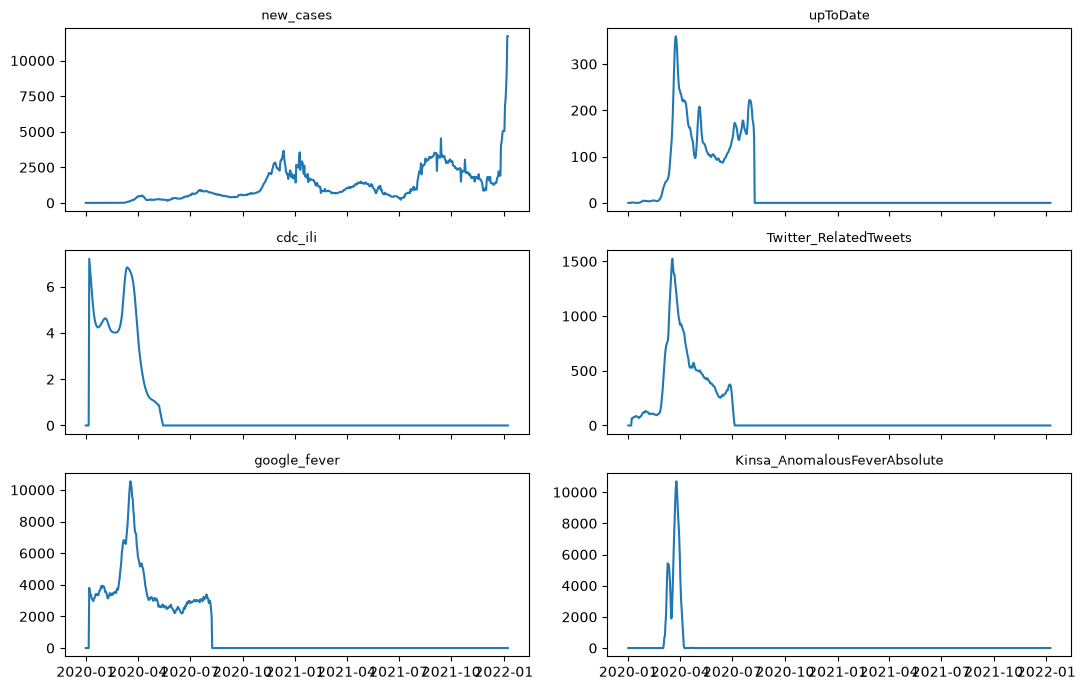

trace                           active window            best lag (days)  interpretation      r
upToDate                        2020-01-07 to 2020-08-08    -4             leads cases       0.64
cdc_ili                         2020-01-07 to 2020-05-14   +19             lags cases        -0.82
Twitter_RelatedTweets           2020-01-07 to 2020-07-04   -17             leads cases       0.62
google_fever                    2020-01-07 to 2020-08-08   +21             lags cases        -0.51
Kinsa_AnomalousFeverAbsolute    2020-03-03 to 2020-04-26   +15             lags cases        -0.81


In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, os

CANDIDATES = ['../data/covid_traces_WA.csv', 'data/covid_traces_WA.csv', './covid_traces_WA.csv']
path = next((p for p in CANDIDATES if os.path.exists(p)), CANDIDATES[0])
df = pd.read_csv(path)
df['date'] = pd.to_datetime(df['date'], format='%m/%d/%y')

TRACES = ['new_cases', 'upToDate', 'cdc_ili', 'Twitter_RelatedTweets', 'google_fever', 'Kinsa_AnomalousFeverAbsolute']

fig, axes = plt.subplots(3, 2, figsize=(11, 7), sharex=True)
for ax, col in zip(axes.ravel(), TRACES):
    ax.plot(df['date'], df[col])
    ax.set_title(col, fontsize=9)
plt.tight_layout()
plt.savefig('../covid_wa_6panel.png', dpi=150)
plt.show()

# NB: each trace only has real signal during Wave 1 (~Jan-Aug 2020) and each one's active
# window ends at a different date (Kinsa stops in Apr, cdc_ili in May, others later) --
# new_cases itself keeps fluctuating through 2022. Comparing over a shared window would
# zero-pad the shorter traces' tails and bias the correlation, so each trace is compared
# to cases only over its OWN active (nonzero) date range.
def best_lag(cases, trace, max_lag=21):
    cases = (cases - cases.mean()) / (cases.std() + 1e-9)
    trace = (trace - trace.mean()) / (trace.std() + 1e-9)
    lags = range(-max_lag, max_lag + 1)
    corrs = []
    for lag in lags:
        if lag < 0:
            c, t = cases[-lag:], trace[:lag]
        elif lag > 0:
            c, t = cases[:-lag], trace[lag:]
        else:
            c, t = cases, trace
        corrs.append(np.corrcoef(c, t)[0, 1])
    i = int(np.argmax(np.abs(corrs)))  # lag with the strongest relationship, either sign
    return list(lags)[i], corrs[i]

print(f"{'trace':30s}  active window            best lag (days)  interpretation      r")
for col in TRACES[1:]:
    active = df.loc[df[col] != 0, 'date']
    window = df[(df['date'] >= active.min()) & (df['date'] <= active.max())]
    lag, corr = best_lag(window['new_cases'], window[col])
    tag = 'leads cases' if lag < 0 else ('lags cases' if lag > 0 else 'in sync')
    print(f'{col:30s}  {active.min().date()} to {active.max().date()}  {lag:+4d}             {tag:16s}  {corr:.2f}')


## Step 1: the growth factor alpha

> *For new_cases, slide an 11-day window: in each window regress the last 10 days on the*
> *previous 10 with NO intercept, and store the slope as alpha for that day. Then make a*
> *3-panel plot: cases, alpha with a line at 1, and a 0/1 flag for alpha > 1. Explain what*
> *alpha means.*


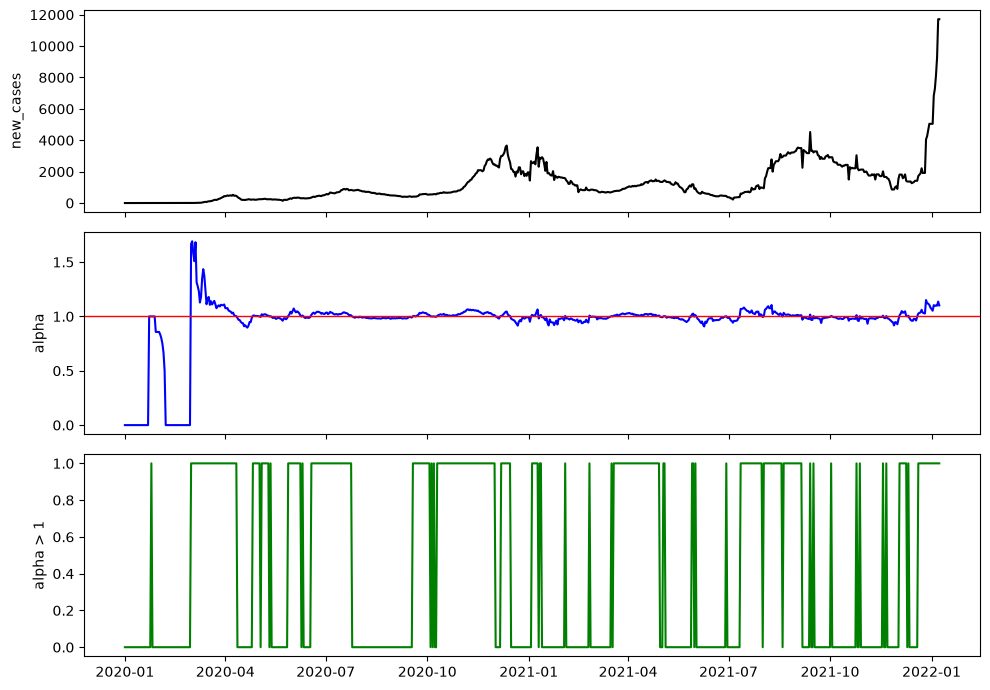

In [2]:
from sklearn.linear_model import LinearRegression

def growth_alpha(x, window=10):
    """Sliding 11-day window: regress the last `window` days on the previous `window`
    days, through the origin (no intercept). The slope alpha is the day-over-day
    growth multiplier implied by that window: cases_t ~= alpha * cases_{t-window}.
    alpha > 1 means cases grew over the window; alpha < 1 means they shrank."""
    x = np.asarray(x, float)
    n = len(x)
    alpha = np.zeros(n)
    for i in range(window, n):
        before = x[i - window:i]        # previous `window` days
        after = x[i - window + 1:i + 1]  # last `window` days (one step ahead of `before`)
        lr = LinearRegression(fit_intercept=False).fit(before.reshape(-1, 1), after)
        alpha[i] = lr.coef_[0]
    return alpha

alpha = growth_alpha(df['new_cases'])

fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
axes[0].plot(df['date'], df['new_cases'], 'k')
axes[0].set_ylabel('new_cases')
axes[1].plot(df['date'], alpha, 'b')
axes[1].axhline(1, color='r', lw=1)
axes[1].set_ylabel('alpha')
axes[2].plot(df['date'], (alpha > 1).astype(int), 'g')
axes[2].set_ylabel('alpha > 1')
plt.tight_layout()
plt.savefig('../covid_wa_alpha.png', dpi=150)
plt.show()


## Step 2: detect outbreak starts

> *When alpha > 1 for 10 consecutive days, mark that 10th day as an outbreak start (only*
> *the first such day); when alpha < 1 for 10 consecutive days the outbreak is over and a*
> *later run can start a new one. Implement it, print the detected start dates, and mark*
> *them on the case-count plot.*

**Your check:** do the marks line up with where you said outbreaks start in Step 0?


detected outbreak starts:
   2020-03-10
   2020-06-06
   2020-09-27
   2021-03-28
   2021-07-21
   2021-12-29


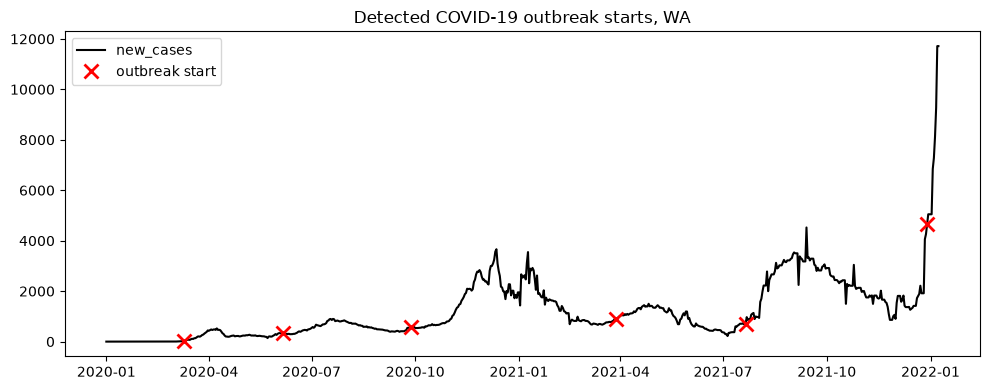

In [3]:
def detect_outbreaks(alpha, run=10):
    """Mark an outbreak start on the day a `run`-day streak of alpha>1 completes
    (only the first such day per outbreak); the outbreak ends once a `run`-day
    streak of alpha<1 completes, allowing a later run to start a new outbreak."""
    n = len(alpha)
    starts = np.zeros(n, int)
    active = False
    for i in range(run, n):
        window = alpha[i - run + 1:i + 1]
        if (window > 1).all():
            if not active:
                active = True
                starts[i] = 1
        elif (window < 1).all():
            active = False
    return starts

starts = detect_outbreaks(alpha)
start_idx = np.where(starts == 1)[0]

print('detected outbreak starts:')
for i in start_idx:
    print('  ', df['date'].iloc[i].date())

plt.figure(figsize=(10, 4))
plt.plot(df['date'], df['new_cases'], 'k', label='new_cases')
plt.plot(df['date'].iloc[start_idx], df['new_cases'].iloc[start_idx], 'rx', ms=10, mew=2, label='outbreak start')
plt.legend(); plt.title('Detected COVID-19 outbreak starts, WA')
plt.tight_layout()
plt.savefig('../covid_wa_outbreak_starts.png', dpi=150)
plt.show()


## Step 3: multi-trace early warning

> *Repeat the alpha + outbreak detection for every trace. For each trace, report how many*
> *days its first outbreak leads (negative) or lags (positive) the case-count outbreak,*
> *and redo the 6-panel plot with each trace's starts marked.*


trace                           first outbreak start   lead/lag vs cases (days)
new_cases                       2020-03-10             0 (reference)
upToDate                        2020-01-31             -39  (leads)
cdc_ili                         2020-02-07             -32  (leads)
Twitter_RelatedTweets           2020-01-31             -39  (leads)
google_fever                    2020-01-29             -41  (leads)
Kinsa_AnomalousFeverAbsolute    2020-03-13             +3  (lags)


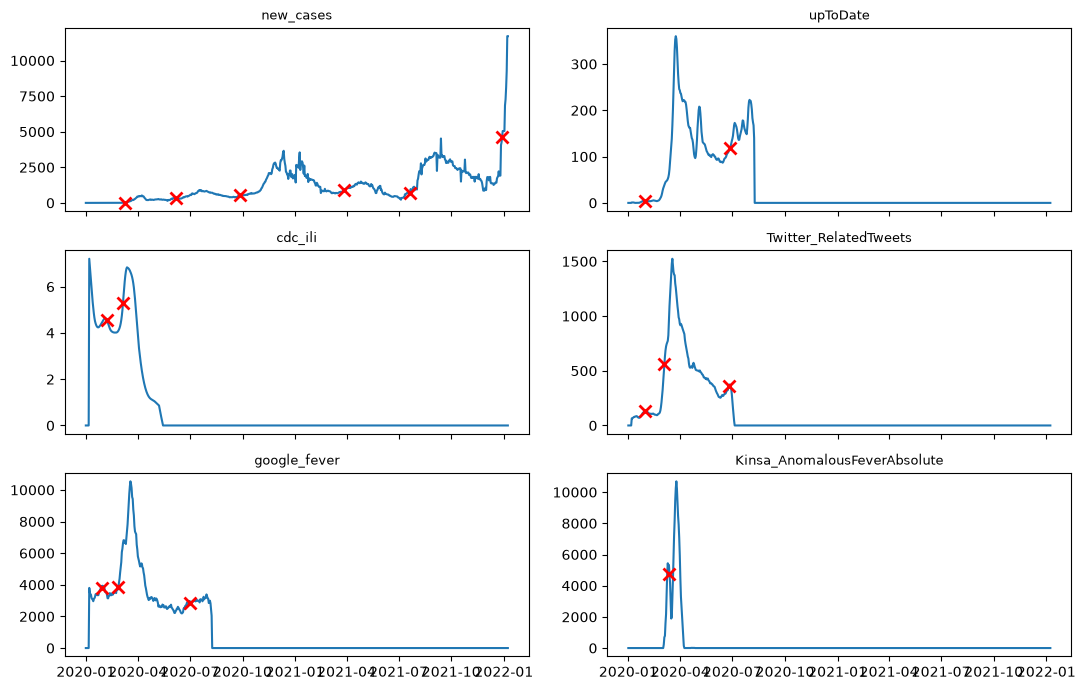

In [4]:
all_starts = {}
for col in TRACES:
    a = growth_alpha(df[col])
    all_starts[col] = detect_outbreaks(a)

case_first = np.where(all_starts['new_cases'] == 1)[0][0]
case_first_date = df['date'].iloc[case_first]

print(f"{'trace':30s}  first outbreak start   lead/lag vs cases (days)")
print(f"{'new_cases':30s}  {str(case_first_date.date()):20s}   0 (reference)")
for col in TRACES[1:]:
    idx = np.where(all_starts[col] == 1)[0]
    if len(idx):
        first = idx[0]
        lead_lag = (df['date'].iloc[first] - case_first_date).days
        tag = 'leads' if lead_lag < 0 else ('lags' if lead_lag > 0 else 'in sync')
        print(f'{col:30s}  {str(df["date"].iloc[first].date()):20s}   {lead_lag:+d}  ({tag})')
    else:
        print(f'{col:30s}  {"(none detected)":20s}')

fig, axes = plt.subplots(3, 2, figsize=(11, 7), sharex=True)
for ax, col in zip(axes.ravel(), TRACES):
    ax.plot(df['date'], df[col])
    idx = np.where(all_starts[col] == 1)[0]
    ax.plot(df['date'].iloc[idx], df[col].iloc[idx], 'rx', ms=8, mew=2)
    ax.set_title(col, fontsize=9)
plt.tight_layout()
plt.savefig('../covid_wa_6panel_outbreaks.png', dpi=150)
plt.show()


### Zoomed in: each trace over its own active window

The shared x-axis above squashes every trace's real signal into a sliver at the left
edge. Re-plotting each trace only over its own nonzero date range (cases shown over
that same window, for reference) makes the shape -- and the outbreak marks -- readable.


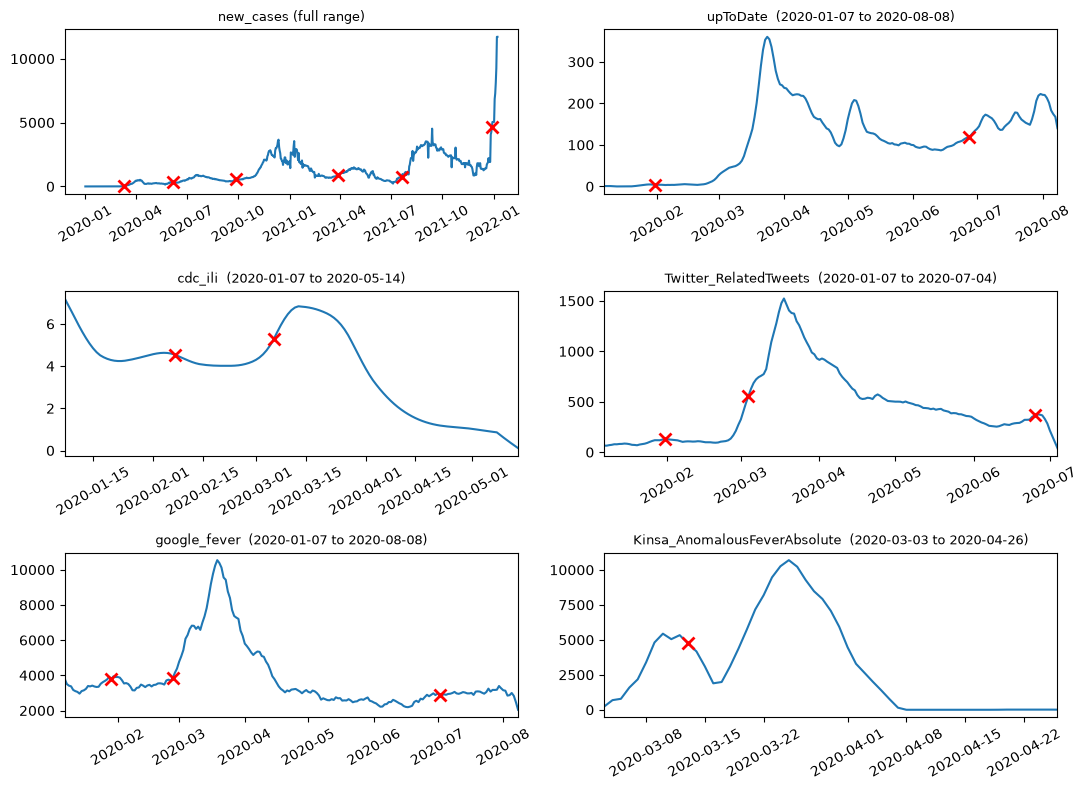

In [5]:
fig, axes = plt.subplots(3, 2, figsize=(11, 8))
axes = axes.ravel()

# new_cases: full range, for reference
ax0 = axes[0]
case_idx = np.where(all_starts['new_cases'] == 1)[0]
ax0.plot(df['date'], df['new_cases'])
ax0.plot(df['date'].iloc[case_idx], df['new_cases'].iloc[case_idx], 'rx', ms=8, mew=2)
ax0.set_title('new_cases (full range)', fontsize=9)
ax0.tick_params(axis='x', rotation=30)

# each trace: zoomed to its own nonzero window
for ax, col in zip(axes[1:], TRACES[1:]):
    active_dates = df.loc[df[col] != 0, 'date']
    lo, hi = active_dates.min(), active_dates.max()
    window = df[(df['date'] >= lo) & (df['date'] <= hi)]
    idx = np.where(all_starts[col] == 1)[0]
    idx = [i for i in idx if lo <= df['date'].iloc[i] <= hi]

    ax.plot(window['date'], window[col])
    ax.plot(df['date'].iloc[idx], df[col].iloc[idx], 'rx', ms=8, mew=2)
    ax.set_title(f'{col}  ({lo.date()} to {hi.date()})', fontsize=9)
    ax.set_xlim(lo, hi)
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../covid_wa_6panel_outbreaks_zoomed.png', dpi=150)
plt.show()


### How does a red X (outbreak-start tick) actually get placed?

Two things have to happen on the day a tick appears:
1. **The streak**: alpha has been `> 1` for 10 straight days (a rolling counter that resets
   to 0 the moment alpha dips back to `<= 1`).
2. **The gate**: no outbreak was already active. Once a tick fires, the detector stays
   "active" and won't fire again until alpha has *also* had a 10-day streak `< 1` (a full
   decline) -- so hitting the 10-day growth streak a second time while still active does
   **not** produce a second tick.

The plot below makes both layers visible for `upToDate` and `google_fever`: raw trace,
alpha, the consecutive-day growth streak (dashed line at the 10-day trigger), and the
active/inactive state. Every place the streak counter *touches* 10 is a potential trigger;
only the ones where the state was inactive turn into an actual red X.


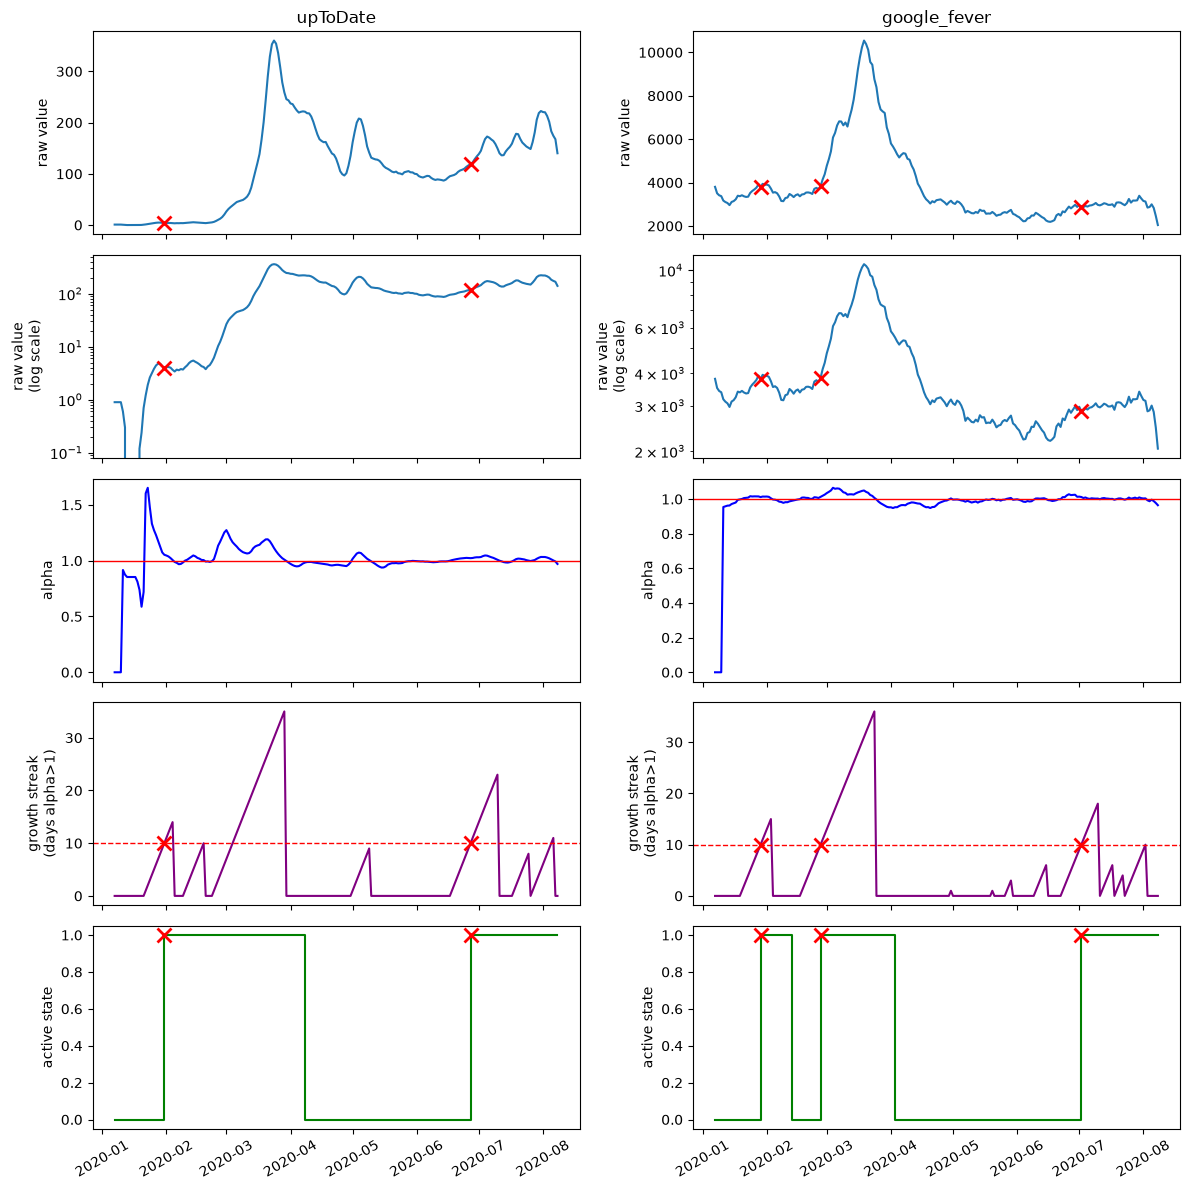

In [6]:
def outbreak_state(alpha, run=10):
    """Like detect_outbreaks, but also returns the day-by-day active/inactive state
    (not just the start ticks) so the gating logic can be plotted."""
    n = len(alpha)
    starts = np.zeros(n, int)
    state = np.zeros(n, int)
    active = False
    for i in range(run, n):
        w = alpha[i - run + 1:i + 1]
        if (w > 1).all():
            if not active:
                active = True
                starts[i] = 1
        elif (w < 1).all():
            active = False
        state[i] = int(active)
    return starts, state

def growth_streak(alpha):
    """Consecutive-day counter: how many days in a row alpha has been > 1, resetting
    to 0 the moment alpha <= 1. Hitting 10 here is the *candidate* trigger."""
    streak = np.zeros(len(alpha), int)
    for i in range(1, len(alpha)):
        streak[i] = streak[i - 1] + 1 if alpha[i] > 1 else 0
    return streak

fig, axes = plt.subplots(5, 2, figsize=(12, 12), sharex='col')

for col_i, col in enumerate(['upToDate', 'google_fever']):
    a = growth_alpha(df[col])
    streak = growth_streak(a)
    starts, state = outbreak_state(a)
    start_idx = np.where(starts == 1)[0]

    active_dates = df.loc[df[col] != 0, 'date']
    lo, hi = active_dates.min(), active_dates.max()
    m = (df['date'] >= lo) & (df['date'] <= hi)

    ax = axes[:, col_i]
    ax[0].plot(df['date'][m], df[col][m])
    ax[0].plot(df['date'].iloc[start_idx], df[col].iloc[start_idx], 'rx', ms=10, mew=2)
    ax[0].set_title(col); ax[0].set_ylabel('raw value')

    ax[1].plot(df['date'][m], df[col][m])
    ax[1].plot(df['date'].iloc[start_idx], df[col].iloc[start_idx], 'rx', ms=10, mew=2)
    ax[1].set_yscale('log')  # 0-valued days simply don't appear (log(0) undefined)
    ax[1].set_ylabel('raw value\n(log scale)')

    ax[2].plot(df['date'][m], a[m], 'b')
    ax[2].axhline(1, color='r', lw=1)
    ax[2].set_ylabel('alpha')

    ax[3].plot(df['date'][m], streak[m], 'purple')
    ax[3].axhline(10, color='r', lw=1, ls='--')
    ax[3].plot(df['date'].iloc[start_idx], streak[start_idx], 'rx', ms=10, mew=2)
    ax[3].set_ylabel('growth streak\n(days alpha>1)')

    ax[4].plot(df['date'][m], state[m], 'g', drawstyle='steps-post')
    ax[4].plot(df['date'].iloc[start_idx], state[start_idx], 'rx', ms=10, mew=2)
    ax[4].set_ylabel('active state')
    ax[4].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../covid_wa_tick_mechanics.png', dpi=150)
plt.show()


## Stretch: majority-vote ensemble onset detector

Run the same growth-factor logic on all five digital traces, and on each day count how
many are simultaneously "growing" (alpha > 1). When a majority (3 of 5) sustain growth
for 10 straight days, call that the ensemble's detected onset -- the idea behind
ARGONet-style early warning: no single trace is trusted alone, but agreement across
traces is.


ensemble (majority-vote) onset date(s):
  2020-01-31   -39 days vs cases (leads)
  2020-03-04   -6 days vs cases (leads)


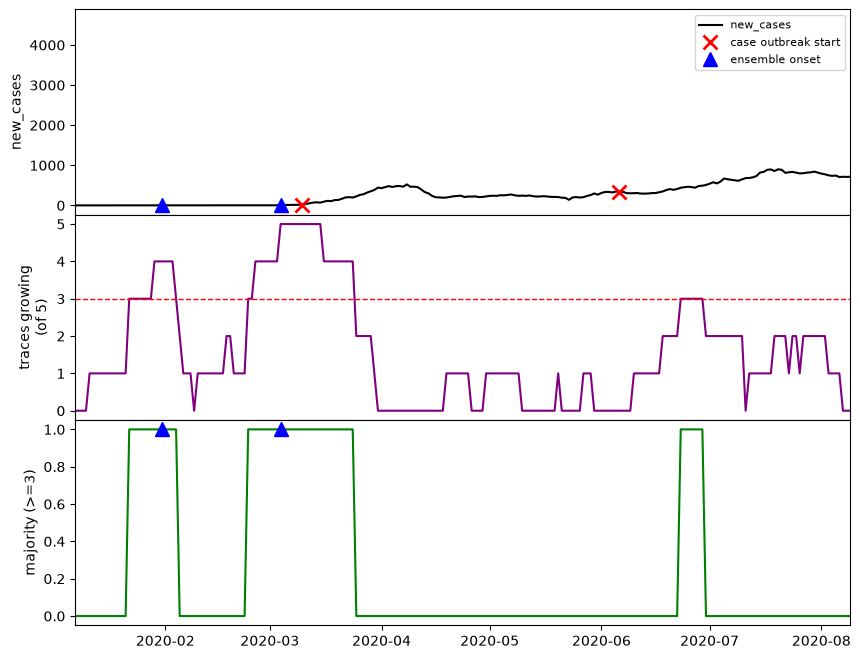

In [7]:
def detect_from_flags(flag, run=10):
    """Same start/stop state machine as detect_outbreaks, but driven by a precomputed
    boolean 'growing' flag instead of thresholding alpha itself."""
    n = len(flag)
    starts = np.zeros(n, int)
    active = False
    for i in range(run, n):
        window = flag[i - run + 1:i + 1]
        if window.all():
            if not active:
                active = True
                starts[i] = 1
        elif (~window).all():
            active = False
    return starts

growing = {col: growth_alpha(df[col]) > 1 for col in TRACES[1:]}
votes = np.sum([growing[col].astype(int) for col in TRACES[1:]], axis=0)
majority = votes >= 3  # 3 of 5 traces agree

ensemble_starts = detect_from_flags(majority)
ensemble_idx = np.where(ensemble_starts == 1)[0]

print('ensemble (majority-vote) onset date(s):')
for i in ensemble_idx:
    lead_lag = (df['date'].iloc[i] - case_first_date).days
    tag = 'leads' if lead_lag < 0 else ('lags' if lead_lag > 0 else 'in sync')
    print(f'  {df["date"].iloc[i].date()}   {lead_lag:+d} days vs cases ({tag})')
if len(ensemble_idx) == 0:
    print('  none detected (majority of 3/5 never sustained for 10 days)')

# zoom to the traces' active window, capped at 2020-08-09
lo = min(df.loc[df[c] != 0, 'date'].min() for c in TRACES[1:])
hi = pd.Timestamp('2020-08-09')
window = df[(df['date'] >= lo) & (df['date'] <= hi)]
wi = window.index

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True, gridspec_kw={'hspace': 0})
axes[0].plot(window['date'], window['new_cases'], 'k', label='new_cases')
axes[0].plot(df['date'].iloc[case_idx], df['new_cases'].iloc[case_idx], 'rx', ms=10, mew=2, label='case outbreak start')
axes[0].plot(df['date'].iloc[ensemble_idx], df['new_cases'].iloc[ensemble_idx], 'b^', ms=10, label='ensemble onset')
axes[0].set_ylabel('new_cases'); axes[0].legend(fontsize=8)

axes[1].plot(window['date'], votes[wi], 'purple')
axes[1].axhline(3, color='r', lw=1, ls='--')
axes[1].set_ylabel('traces growing\n(of 5)')

axes[2].plot(window['date'], majority[wi].astype(int), 'g')
axes[2].plot(df['date'].iloc[ensemble_idx], majority[ensemble_idx].astype(int), 'b^', ms=10)
axes[2].set_ylabel('majority (>=3)')
axes[2].set_xlim(lo, hi)  # sharex: clip all three panels to 2020-01-07 through 2020-08-09

for ax in axes[:-1]:
    ax.tick_params(axis='x', labelbottom=False)

plt.savefig('../covid_wa_ensemble_onset.png', dpi=150)
plt.show()


## Reflection

- You described a detector; the agent wrote the sliding-window regression and the state
  machine.
- The judgment stayed with you: is the alarm early, and is it firing on signal or noise?
- **Next:** Mauricio's COVID research talk, then Day 3, bring your own problem.
